In [1]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

In [2]:
# create image objects

circle_one = sitk.Image(512, 512, sitk.sitkFloat32)
circle_two = sitk.Image(512, 512, sitk.sitkFloat32)

In [3]:
# add metadata

dcm = (1,0,0,1)

circle_one.SetOrigin((0,0))
circle_one.SetSpacing((1,1))
circle_one.SetDirection(dcm)

circle_two.SetOrigin((0,0))
circle_two.SetSpacing((1,1))
circle_two.SetDirection(dcm)

In [4]:
def make_circle(image, center_x, center_y, radius):
    center = image.TransformPhysicalPointToIndex((center_x, center_y))
    print('50mm, 50mm -> \n', center)
    
    for i in range(0, image.GetSize()[0]):
        for j in range(0, image.GetSize()[1]):
    
            pt = image.TransformIndexToPhysicalPoint((i,j))
    
            # radius from center < circle radius, set to 1
            if np.sqrt((center[0] - pt[0])**2 + (center[1] - pt[1])**2) <= radius:
                image.SetPixel(i,j,1)

    return image


In [5]:
circle_one = make_circle(circle_one, 50, 50, 30)
circle_two = make_circle(circle_two, 200, 200, 60)

50mm, 50mm -> 
 (50, 50)
50mm, 50mm -> 
 (200, 200)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

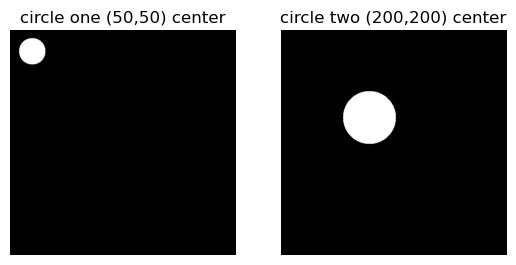

In [6]:
plt.subplot(1,2,1)
plt.imshow(sitk.GetArrayViewFromImage(circle_one), cmap='gray')
plt.title('circle one (50,50) center')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sitk.GetArrayViewFromImage(circle_two), cmap='gray')
plt.title('circle two (200,200) center')
plt.axis('off')

In [7]:
sitk.WriteImage(circle_one, 'data/circle_one.nii.gz')
sitk.WriteImage(circle_two, 'data/circle_two.nii.gz')